<a href="https://colab.research.google.com/github/yanin-dev/ciencias_de_datos/blob/main/Regresi%C3%B3n_scikit_learn_lineal_simple_y_m%C3%BAltiple_Alumno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#REGRESIÓN LINEAL ll

#Carrera: Tecnicatura Superior en Ciencia de Datos e IA

#Institución: IFTS 33 - UOCRA

#Profesora: Marisa Cánovas

#Objetivo de la Práctica

Implementar un modelo de Regresión Lineal utilizando el estándar de la industria (scikit-learn) sobre el dataset Boston House Prices, evolucionando desde la implementación manual con NumPy realizada anteriormente.

Al finalizar esta práctica, serás capaz de:

Aplicar el flujo de trabajo estándar de Machine Learning: División de datos en conjuntos de Entrenamiento (Train) y Prueba (Test) para evaluar la capacidad de generalización del modelo.

Utilizar la API de scikit-learn: Entrenar un modelo LinearRegression para predecir el Value (variable dependiente) a partir de Rooms (variable independiente), delegando el cálculo matricial a la librería.

Evaluar e interpretar el modelo: Calcular y analizar métricas clave (R², RMSE, MAE) sobre el conjunto de Test, comparando la simplicidad y robustez de este enfoque frente a la Ecuación Normal calculada manualmente.

#OLS (Ordinary Least Squares / Mínimos Cuadrados Ordinarios)
Es el método/algoritmo que usa LinearRegression() para encontrar la mejor recta de regresión. Busca los coeficientes (β₀, β₁) que hacen que la recta pase "lo más cerca posible" de todos los puntos.

In [19]:
#sklearn  ols = LinearRegression().fit(X_train, y_train)
#NumPy    coeficientes = np.linalg.inv(X_ones.T @ X_ones) @ X_ones.T @ y

In [20]:
## Paso 1: Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive

## Paso 2: Cargar y explorar los datos

# 1. Cargar Google Drive
drive.mount("/content/drive") # para abrir la puerta a elegir un archivo especifico.

# 2. Leer el archivo CSV
df = pd.read_csv("/content/drive/My Drive/csdatos csvdejunio/Boston House Prices.csv")

# 3. Verificar que todo se haya cargado bien
display(df.head(10))  # primeras 10 filas

# Exploración inicial
print("=== EXPLORACIÓN DE DATOS ===")
print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación general:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Rooms,Distance,Value
0,6.575,4.0900,24.0
1,6.421,4.9671,21.6
2,7.185,4.9671,34.7
3,6.998,6.0622,33.4
4,7.147,6.0622,36.2
5,6.430,6.0622,28.7
6,6.012,5.5605,22.9
7,6.172,5.9505,27.1
8,5.631,6.0821,16.5
9,6.004,6.5921,18.9


=== EXPLORACIÓN DE DATOS ===
Forma del dataset: (506, 3)

Primeras 5 filas:
   Rooms  Distance  Value
0  6.575    4.0900   24.0
1  6.421    4.9671   21.6
2  7.185    4.9671   34.7
3  6.998    6.0622   33.4
4  7.147    6.0622   36.2

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rooms     506 non-null    float64
 1   Distance  506 non-null    float64
 2   Value     506 non-null    float64
dtypes: float64(3)
memory usage: 12.0 KB
None

Estadísticas descriptivas:
            Rooms    Distance       Value
count  506.000000  506.000000  506.000000
mean     6.284634    3.795043   22.532806
std      0.702617    2.105710    9.197104
min      3.561000    1.129600    5.000000
25%      5.885500    2.100175   17.025000
50%      6.208500    3.207450   21.200000
75%      6.623500    5.188425   25.000000
max      8.780000   12.126500   50.00

In [21]:
X = df['Rooms'].values  # Variable independiente (1D)
y = df['Value'].values  # Variable dependiente (1D)

In [22]:
#  Imports mínimos
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Reshape y división
X_reshaped = X.reshape(-1, 1) #Transforma nuestro vector de 1 dimensión (una lista plana de números) en una matriz de 2 dimensiones (una columna).
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

# Entrenar SOLO OLS
ols = LinearRegression().fit(X_train, y_train)
#calcula los coeficientes
print("Coeficientes (OLS):", ols.coef_)

#Evaluación (método `.score`):
# Evaluar R² (Coeficiente de Determinación) mide qué porcentaje de la variación del precio es explicado por tu modelo de regresión.
r2_ols = ols.score(X_test, y_test)
print(f"Coeficiente de Determinación (R²): {r2_ols}")
#1. Predice los precios usando `X_test` (las habitaciones de las casas que el modelo nunca vio).
#2. Compara esas predicciones con los precios reales de `y_test` y calcula el **R²**.


# Generar predicciones
y_pred_ols = ols.predict(X_test)

#El método.predict(X_test)utiliza los coeficientes que el modelo aprendió durante el entrenamiento para estimar el valor de las propiedades en el conjunto de test
#generando un nuevo array con los precios predichos
#(`y_pred_ols`) que luego compararemos con la realidad.

# =============================================================================
# 📏 MÉTRICAS DE EVALUACIÓN: ¿Qué tan bien predijo el modelo?
# =============================================================================

# 1️⃣ MSE (Error Cuadrático Medio)
mse_ols = mean_squared_error(y_test, y_pred_ols)
# → Promedio de (y_real - y_pred)². Penaliza errores grandes.
#   Unidad: $² (no interpretable directamente, pero útil para optimizar)

# 2️⃣RMSE(Raíz del Error Cuadrático Medio)Penaliza fuerte los outliers.​Eleva al cuadrado → penaliza errores gdes. Lo usas si Tenés outliers y querés detectarlos.
rmse_ols = np.sqrt(mse_ols)
# → Vuelve a unidades originales ($k).
#   Interpretable: "En promedio, me equivoco en $X mil por predicción"

# 3️⃣ MAE (Error Absoluto Medio)   Trata todos los errores por igual Toma valor absoluto Lo usas si  Tenés outliers y querés ignorarlos
mae_ols = mean_absolute_error(y_test, y_pred_ols)
# → Promedio de |y_real - y_pred|.
#   Interpretable: "En promedio, me equivoco en $X mil (sin importar si es de más o de menos)"

# Mostrar resultados
print("\n" + "="*45)
print("📊 MODELO: OLS (Sin regularización)")
print("="*45)
print(f"{'Métrica':<18} {'Valor':>12}")
print("-"*32)
print(f"{'R² (Ajuste)':<18} {r2_ols:>12.3f}")
print(f"{'MSE (Error²)':<18} {mse_ols:>12.3f}")   # ← ¡ESTE FALTABA!
print(f"{'RMSE (Error típico)':<18} {rmse_ols:>12.3f}")
print(f"{'MAE (Error absoluto)':<18} {mae_ols:>12.3f}")
print("-"*32)
print(f"{'β₁ (Coeficiente)':<18} {ols.coef_[0]:>12.3f}")
print(f"{'β₀ (Intercepto)':<18} {ols.intercept_:>12.3f}") # ← ¡MUY RECOMENDABLE AGREGARLO!
print("="*45)

Coeficientes (OLS): [9.34830141]
Coeficiente de Determinación (R²): 0.3707569232254778

📊 MODELO: OLS (Sin regularización)
Métrica                   Valor
--------------------------------
R² (Ajuste)               0.371
MSE (Error²)             46.145
RMSE (Error típico)        6.793
MAE (Error absoluto)        4.478
--------------------------------
β₁ (Coeficiente)          9.348
β₀ (Intercepto)         -36.246


#verificar los outliers

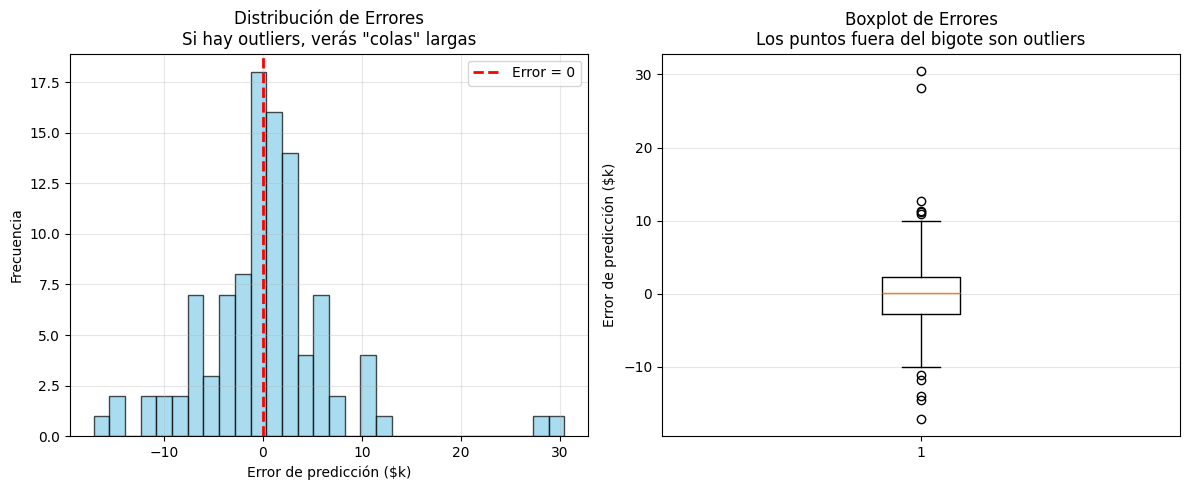


🔍 TOP 5 ERRORES MÁS GRANDES (posibles outliers):
Predicción #1:
  • Real: $27.50k
  • Predicho: $-2.96k
  • Error: $+30.46k ← OUTLIER

Predicción #2:
  • Real: $50.00k
  • Predicho: $21.86k
  • Error: $+28.14k ← OUTLIER

Predicción #3:
  • Real: $15.00k
  • Predicho: $32.12k
  • Error: $-17.12k ← OUTLIER

Predicción #4:
  • Real: $9.60k
  • Predicho: $24.15k
  • Error: $-14.55k 

Predicción #5:
  • Real: $10.90k
  • Predicho: $24.94k
  • Error: $-14.04k 



In [23]:
import matplotlib.pyplot as plt

# 1. Calcular todos los errores individuales
errores = y_test - y_pred_ols

# 2. Visualizar la distribución de errores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
plt.xlabel('Error de predicción ($k)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores\nSi hay outliers, verás "colas" largas')
plt.legend()
plt.grid(alpha=0.3)

# 3. Boxplot para detectar outliers visualmente
plt.subplot(1, 2, 2)
plt.boxplot(errores, vert=True)
plt.ylabel('Error de predicción ($k)')
plt.title('Boxplot de Errores\nLos puntos fuera del bigote son outliers')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. Mostrar los 5 errores más grandes (los outliers)
print("\n🔍 TOP 5 ERRORES MÁS GRANDES (posibles outliers):")
print("="*50)
indices_ordenados = np.argsort(np.abs(errores))[::-1]
for i in range(5):
    idx = indices_ordenados[i]
    print(f"Predicción #{i+1}:")
    print(f"  • Real: ${y_test[idx]:.2f}k")
    print(f"  • Predicho: ${y_pred_ols[idx]:.2f}k")
    print(f"  • Error: ${errores[idx]:+.2f}k {'← OUTLIER' if abs(errores[idx]) > 15 else ''}")
    print()

## 🛡️ Regularización en Acción: OLS vs Ridge (L2)


Hasta ahora hemos usado **OLS (Mínimos Cuadrados Ordinarios)**, un método que busca ajustar los datos de entrenamiento lo mejor posible. Sin embargo, a veces esto puede llevar a **overfitting** (sobreajuste), donde el modelo se vuelve demasiado sensible al "ruido" de los datos en lugar de aprender el patrón real.


Para combatir esto, introducimos **Ridge Regression**, que agrega una **penalización L2** a la función de error del modelo.

### 🔍 ¿Cómo funciona Ridge?

1. **El "Freno" (Penalización):** Además de minimizar el error de predicción, Ridge agrega un castigo proporcional al tamaño de los coeficientes al cuadrado ($\alpha \sum \beta^2$).

2. **El Efecto:** Esto "encoge" los coeficientes hacia cero (sin llegar a ser exactamente cero), evitando que tomen valores extremos.

3. **El Parámetro `alpha` (α):** Controla la fuerza de este freno.
   - `alpha = 0` → Es idéntico a OLS (sin penalización).
   - `alpha > 0` → Aplica regularización (a mayor valor, más encoge los coeficientes).


>  **Objetivo de este bloque:** Vamos a entrenar ambos modelos con los mismos datos y comparar si agregar una penalización moderada (`alpha=1.0`) logra que el modelo generalice mejor en datos no vistos (Test), observando si el **RMSE disminuye** y cómo cambia el valor del **coeficiente**.

In [24]:
X = df['Rooms'].values  # Variable independiente (1D)
y = df['Value'].values  # Variable dependiente (1D)

In [25]:
# 1️⃣ Imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Reshape y división
X_reshaped = X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

# 2️⃣ Entrenar ambos modelos
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

# 3️⃣ Evaluar R²
r2_ols = ols.score(X_test, y_test)
r2_ridge = ridge.score(X_test, y_test)

# 4️⃣ Generar predicciones
y_pred_ols = ols.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# 5️⃣ Calcular métricas completas
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# 6️⃣ Mostrar resultados comparativos
print("\n" + "="*50)
print("📊 COMPARACIÓN: OLS vs Ridge (α=1.0)")
print("="*50)
print(f"{'Métrica':<12} {'OLS':>10} {'Ridge':>12}")
print("-"*36)
print(f"{'R²':<12} {r2_ols:>10.3f} {r2_ridge:>12.3f}")
print(f"{'RMSE':<12} {rmse_ols:>10.3f} {rmse_ridge:>12.3f}")
print(f"{'MAE':<12} {mae_ols:>10.3f} {mae_ridge:>12.3f}")
print(f"{'Coeficiente':<12} {ols.coef_[0]:>10.3f} {ridge.coef_[0]:>12.3f}")
print("="*50)

# 💡 Interpretación rápida
print(f"\n🔍 Ridge {'mejora' if rmse_ridge < rmse_ols else 'no mejora'} el error típico vs OLS")


📊 COMPARACIÓN: OLS vs Ridge (α=1.0)
Métrica             OLS        Ridge
------------------------------------
R²                0.371        0.372
RMSE              6.793        6.789
MAE               4.478        4.477
Coeficiente       9.348        9.302

🔍 Ridge mejora el error típico vs OLS


## 🚀 Desafío Práctico: Replicando el flujo con 'Distance'


Ahora que entendemos cómo comparar **OLS vs Ridge** con la variable *Rooms*, es tu turno de aplicar el mismo flujo de trabajo con una nueva variable.


### 🎯 Tu misión:
1. **Preparar los datos:** Usá la variable `Distance` (distancia a centros de empleo) .



In [26]:
X = df['Distance'].values  # Variable independiente (1D)
y = df['Value'].values  # Variable dependiente (1D)

#Regresión múltiple con y sin Ridge

In [27]:
# 1️⃣ Imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Preparar datos con DOS features (¡Corchetes dobles! Ya es 2D, NO hace falta reshape)
X_multi = df[['Rooms', 'Distance']].values
y = df['Value'].values

# División en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 2️⃣ Entrenar ambos modelos
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

# 3️⃣ Evaluar R²
r2_ols = ols.score(X_test, y_test)
r2_ridge = ridge.score(X_test, y_test)

# 4️⃣ Generar predicciones
y_pred_ols = ols.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# 5️⃣ Calcular métricas completas
# --- OLS ---
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

# --- Ridge ---
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# 6️⃣ Mostrar resultados comparativos
print("\n" + "="*65)
print("📊 COMPARACIÓN: Regresión Múltiple (Rooms + Distance)")
print("="*65)
print(f"{'Métrica':<18} {'OLS':>12} {'Ridge (α=1.0)':>15}")
print("-"*47)
print(f"{'R² (Ajuste)':<18} {r2_ols:>12.3f} {r2_ridge:>15.3f}")
print(f"{'MSE (Error²)':<18} {mse_ols:>12.3f} {mse_ridge:>15.3f}")
print(f"{'RMSE (Error típico)':<18} {rmse_ols:>12.3f} {rmse_ridge:>15.3f}")
print(f"{'MAE (Error absoluto)':<18} {mae_ols:>12.3f} {mae_ridge:>15.3f}")
print("-"*47)
print("🔹 COEFICIENTES APRENDIDOS:")
print(f"  • β₁ (Rooms)    : {ols.coef_[0]:>12.3f}  vs  {ridge.coef_[0]:>12.3f}")
print(f"  • β₂ (Distance) : {ols.coef_[1]:>12.3f}  vs  {ridge.coef_[1]:>12.3f}")
print(f"  • β₀ (Intercept): {ols.intercept_:>12.3f}  vs  {ridge.intercept_:>12.3f}")
print("="*65)

# 💡 Interpretación rápida
print(f"\n🔍 Ridge {'mejora' if rmse_ridge < rmse_ols else 'no mejora'} el error típico vs OLS")
print(f"   → Ridge 'encogió' los coeficientes de {ols.coef_[0]:.3f} a {ridge.coef_[0]:.3f} (Rooms)")
print(f"   → Ridge 'encogió' los coeficientes de {ols.coef_[1]:.3f} a {ridge.coef_[1]:.3f} (Distance)")


📊 COMPARACIÓN: Regresión Múltiple (Rooms + Distance)
Métrica                     OLS   Ridge (α=1.0)
-----------------------------------------------
R² (Ajuste)               0.395           0.396
MSE (Error²)             44.381          44.319
RMSE (Error típico)        6.662           6.657
MAE (Error absoluto)        4.297           4.296
-----------------------------------------------
🔹 COEFICIENTES APRENDIDOS:
  • β₁ (Rooms)    :        9.093  vs         9.046
  • β₂ (Distance) :        0.429  vs         0.432
  • β₀ (Intercept):      -36.266  vs       -35.984

🔍 Ridge mejora el error típico vs OLS
   → Ridge 'encogió' los coeficientes de 9.093 a 9.046 (Rooms)
   → Ridge 'encogió' los coeficientes de 0.429 a 0.432 (Distance)


#Desafio: Incluir gráficos

 Ejercicio: Regresión Múltiple con Lasso (L1)

📋 Enunciado:

Ahora que comparaste OLS vs Ridge, es tu turno de explorar Lasso.

Tu misión:
Replicá el mismo flujo de trabajo que hiciste con Ridge, pero ahora usando Lasso (from sklearn.linear_model import Lasso)

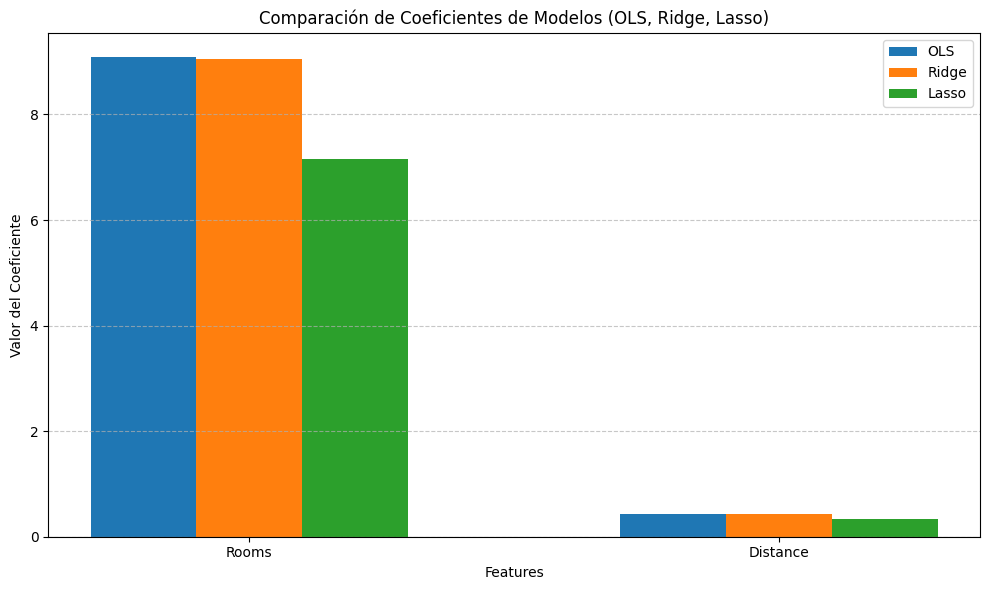

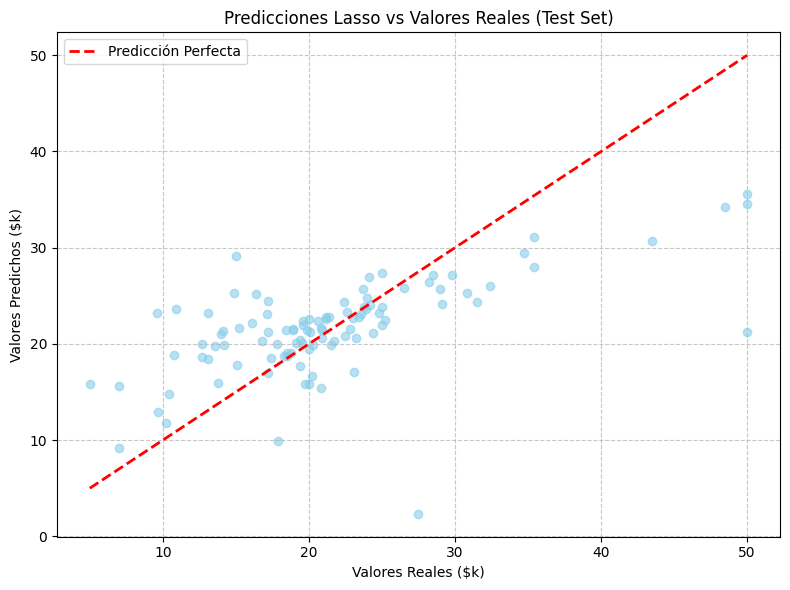

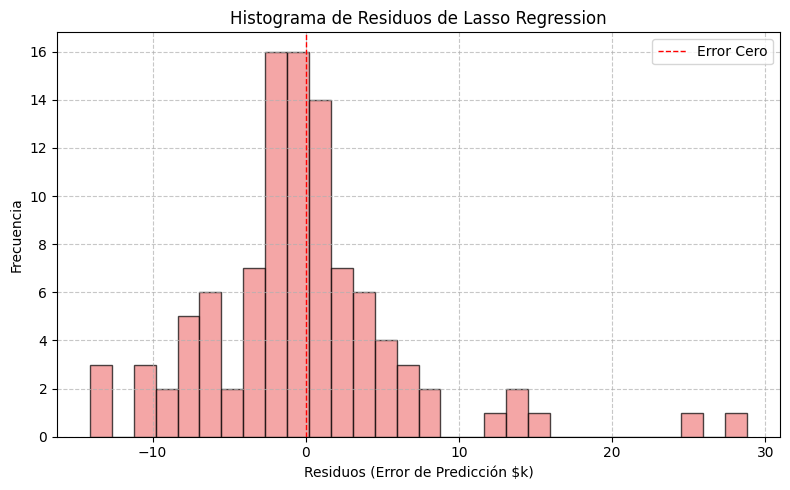

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener coeficientes e interceptos de los modelos
models = {
    'OLS': {'coef': ols.coef_, 'intercept': ols.intercept_},
    'Ridge': {'coef': ridge.coef_, 'intercept': ridge.intercept_},
    'Lasso': {'coef': lasso.coef_, 'intercept': lasso.intercept_}
}

features = ['Rooms', 'Distance']

# 1. Gráfico de Coeficientes Comparativo
plt.figure(figsize=(10, 6))
width = 0.2
x = np.arange(len(features))

for i, (name, model_data) in enumerate(models.items()):
    coefs = model_data['coef']
    plt.bar(x + i * width - width, coefs, width, label=name)

plt.xlabel('Features')
plt.ylabel('Valor del Coeficiente')
plt.title('Comparación de Coeficientes de Modelos (OLS, Ridge, Lasso)')
plt.xticks(x, features)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

# 2. Gráfico de Dispersión de Predicciones vs Reales para Lasso (el de mejor RMSE)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.6, color='skyblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.xlabel('Valores Reales ($k)')
plt.ylabel('Valores Predichos ($k)')
plt.title('Predicciones Lasso vs Valores Reales (Test Set)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Histograma de Residuos (Errores) para Lasso
residuals_lasso = y_test - y_pred_lasso
plt.figure(figsize=(8, 5))
plt.hist(residuals_lasso, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Error Cero')
plt.xlabel('Residuos (Error de Predicción $k)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos de Lasso Regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [29]:
# 1️⃣ Imports (Incluyendo Lasso)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Preparar datos con DOS features (Rooms y Distance)
X_multi = df[['Rooms', 'Distance']].values # Ya es 2D, no necesita reshape
y = df['Value'].values

# División en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 2️⃣ Entrenar los tres modelos
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1.0).fit(X_train, y_train)

# 3️⃣ Evaluar R²
r2_ols = ols.score(X_test, y_test)
r2_ridge = ridge.score(X_test, y_test)
r2_lasso = lasso.score(X_test, y_test)

# 4️⃣ Generar predicciones
y_pred_ols = ols.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# 5️⃣ Calcular métricas completas
# --- OLS ---
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

# --- Ridge ---
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# --- Lasso ---
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

# 6️⃣ Mostrar resultados comparativos
print("\n" + "="*75)
print("📊 COMPARACIÓN: Regresión Múltiple (OLS vs Ridge vs Lasso)")
print("="*75)
print(f"{'Métrica':<18} {'OLS':>12} {'Ridge (α=1.0)':>15} {'Lasso (α=1.0)':>15}")
print("-"*60)
print(f"{'R² (Ajuste)':<18} {r2_ols:>12.3f} {r2_ridge:>15.3f} {r2_lasso:>15.3f}")
print(f"{'MSE (Error²)':<18} {mse_ols:>12.3f} {mse_ridge:>15.3f} {mse_lasso:>15.3f}")
print(f"{'RMSE (Error típico)':<18} {rmse_ols:>12.3f} {rmse_ridge:>15.3f} {rmse_lasso:>15.3f}")
print(f"{'MAE (Error absoluto)':<18} {mae_ols:>12.3f} {mae_ridge:>15.3f} {mae_lasso:>15.3f}")
print("-"*60)
print("🔹 COEFICIENTES APRENDIDOS:")
print(f"  • β₁ (Rooms)    : {ols.coef_[0]:>12.3f}  vs  {ridge.coef_[0]:>12.3f}  vs  {lasso.coef_[0]:>12.3f}")
print(f"  • β₂ (Distance) : {ols.coef_[1]:>12.3f}  vs  {ridge.coef_[1]:>12.3f}  vs  {lasso.coef_[1]:>12.3f}")
print(f"  • β₀ (Intercept): {ols.intercept_:>12.3f}  vs  {ridge.intercept_:>12.3f}  vs  {lasso.intercept_:>12.3f}")
print("="*75)

# 💡 Interpretación rápida para Lasso
print(f"\n🔍 Lasso con α=1.0 {'mejora' if rmse_lasso < rmse_ols else 'no mejora'} el error típico vs OLS")
print(f"   → Lasso 'encogió' el coeficiente de Rooms de {ols.coef_[0]:.3f} a {lasso.coef_[0]:.3f}")
print(f"   → Lasso 'encogió' el coeficiente de Distance de {ols.coef_[1]:.3f} a {lasso.coef_[1]:.3f}")


📊 COMPARACIÓN: Regresión Múltiple (OLS vs Ridge vs Lasso)
Métrica                     OLS   Ridge (α=1.0)   Lasso (α=1.0)
------------------------------------------------------------
R² (Ajuste)               0.395           0.396           0.400
MSE (Error²)             44.381          44.319          43.994
RMSE (Error típico)        6.662           6.657           6.633
MAE (Error absoluto)        4.297           4.296           4.452
------------------------------------------------------------
🔹 COEFICIENTES APRENDIDOS:
  • β₁ (Rooms)    :        9.093  vs         9.046  vs         7.156
  • β₂ (Distance) :        0.429  vs         0.432  vs         0.336
  • β₀ (Intercept):      -36.266  vs       -35.984  vs       -23.682

🔍 Lasso con α=1.0 mejora el error típico vs OLS
   → Lasso 'encogió' el coeficiente de Rooms de 9.093 a 7.156
   → Lasso 'encogió' el coeficiente de Distance de 0.429 a 0.336
